### Neural Network Classification with PyTorch.

Classification is a problem of predicting whether something is ne thing or the other  (there can be multiple things as the options).

### Make classification data and get it ready.

In [45]:
import sklearn

In [46]:
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000

# Create make_circles
X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state=42)


In [ ]:
len(X), len(y)

(1000, 1000)

In [ ]:
print(f"First 5 samples of X:\n {X[:5]}")
print(f"First 5 samples of y:\n {y[:5]}") 

First 5 samples of X:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y:
 [1 1 1 1 0]


In [ ]:
# Make dataframe of circle data

import pandas as pd

circles = pd.DataFrame({"X1": X[:, 0],
                        "X2": X[:, 1],
                        "label":y})
circles.head(10 )

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


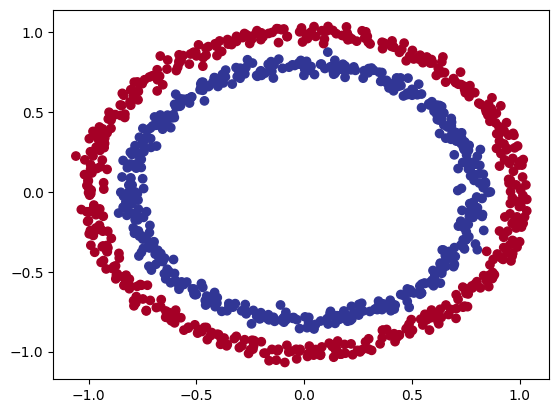

In [ ]:
# Visualize 

import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],
            y=X[:,1],
            c = y,
            cmap = plt.cm.RdYlBu);

Note: The data we are working with us often called a toy dataset, a dataset that is small but still enough to practice the fundamentals.

### Check input and output shape


In [ ]:
X.shape, y.shape

((1000, 2), (1000,))

In [ ]:
type(X)

numpy.ndarray

###  Turning data into tensors and creating Train and test split 



In [ ]:
# view the first example of features and labels 
x_sample  = X[0]
y_sample = y[0]

print(f"Values for one sample of X: {x_sample} and the same for y: {y_sample}")
print(f"SHapes for one sample of x: {x_sample.shape} and te same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
SHapes for one sample of x: (2,) and te same for y: ()


In [ ]:
type(X)

numpy.ndarray

In [ ]:
import torch 
torch.__version__ 

'2.9.1+cu128'

In [ ]:
# Turn data into tensors 

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [ ]:
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [ ]:
torch.manual_seed(42)

In [ ]:
from sklearn.model_selection import train_test_split
# Split data into learning and test sets

# **********Manual Approach***********
"""
split = int(0.8 * len(X)) 


X_train,y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]
"""


# **********Using Scikit-learn***********

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y, 
                                                    test_size=0.2, # 20% of data will be reserved for testing
                                                    random_state=42)

In [ ]:
len(X_train), len(X_test)

(800, 200)

### 2. Setting Up for a Model 

Model's task is to classify the blue and red dots.

To do so, we want to:
1. Setup device agnostic code
2. Construct a model (by subclassing nn.Module)
3. Define a loss function and optimiser 
4. Creating a training and test loop 

In [ ]:
# import PyTorch and nn

import torch
from torch import nn

# Make device agnostic code 

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

### Building a Model

That:

1. Subclass `nn.Module` 
2. Create 2 `nn.Linear()` layers that are capable of handling the shapes of our data
3. Defines a `forward()` method that outlines the forward pass (or forward computation) of the model 
4. Instantiate an instance of our model class and send it to the target device


In [ ]:
# 1. Construct a model that subclasses nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling data shape
        self.layer_1 = nn.Linear(in_features =2, out_features= 5)  # takes in 2 layers and upscale it to 5 features
        self.layer_2 = nn.Linear(in_features=5, out_features=1)   # takes in 5 features from previous layer and outputs a single feature (same shape as y)
    
    # defines a forward method that outlines the forward pass.
    def forward(self, x):
        return self.layer_2(self.layer_1(x)) #x --> layer_1 --> layer_2 -->  output
    

# 4. Instantiate an instance of our model class and send it to the target device.
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
next(model_0.parameters()).device

device(type='cpu')

### Using nn.Sequential to Rebuild Model 

In [ ]:
model_1 = nn.Sequential(
                       nn.Linear(in_features = 2, out_features = 5),
                       nn.Linear(in_features = 5, out_features = 1)
).to(device)
 
model_1

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
model_1.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]])),
             ('0.bias', tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370])),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]])),
             ('1.bias', tensor([-0.1213]))])

In [ ]:
# Make Predictions
with torch.inference_mode():
    untrained_preds =  model_1(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst ten predictions: \n {torch.round(untrained_preds[:10])}")
print(f"\nFirst 10 labels: \n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First ten predictions: 
 tensor([[-0.],
        [-0.],
        [0.],
        [-0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [-0.]])

First 10 labels: 
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [ ]:
X_test[:10]

tensor([[-0.3752,  0.6827],
        [ 0.0154,  0.9600],
        [-0.7028, -0.3147],
        [-0.2853,  0.9664],
        [ 0.4024, -0.7438],
        [ 0.6323, -0.5711],
        [ 0.8561,  0.5499],
        [ 1.0034,  0.1903],
        [-0.7489, -0.2951],
        [ 0.0538,  0.9739]])

### Setup loss functions and optimiser 

The loss function and opimizer to be used is problem specific

For Regression ---> Mean Absolute error (MAE) or Mean Squared Error (MSE)

For Classification ---> Binary Cross entropy or Categorical Cross Entropy

The loss function calculates how wrong our model predictions are.

for the optimisers, two of the most common and useful are SGD and Adam,PyTorch has many built-in options.

for the loss function we are going to use `torch.nn.BCEWithLogitLoss()`.

In [ ]:
# Setup the loss function
#loss_fn = nn.BCELoss() # requires the input to have gone through sigmoid activation function before passing to BCELoss
loss_fn = nn.BCEWithLogitsLoss()  #BCEWithLogitLoss = sigmoid activation function built-in with pytorch.

optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr = 0.1)

In [ ]:
# Calculate Accuracy - what percentage of the test data did the model predict right? 
# Accuracy = True positive/(True Positive + True Negative) * 100

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_pred)) * 100
    return acc
 

### Training the Model 

1. Forward Pass 
2. Calculate the loss 
3. Optimiser zero grad
4. Loss Backward (back propagation)
5. Optimizer step (gradient descent)

### Going from raw logits  --> prediction probabilities --> prediction labels

our model outputs are going to be raww **Logits**.

We can convert these **Logits** into **prediction probabilities** by passing them to some kind of activation function(e.g. Sigmoid for binary cross-entropy and softmax for multi-class classification)

Then we can convert our models's probilities to **prediction labels** by either rounding them or taking taking the `argmax`

In [ ]:
# Viewing the first five outputs of the forward pass on the test data
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.1269],
        [-0.0967],
        [-0.1908],
        [-0.1089],
        [-0.1667]])

In [ ]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

Last Checkout --> 10:20:34

In [ ]:
# Use the sigmoid activation function on our model Logits to turn them into prediction probabilities

y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs 

tensor([[0.4683],
        [0.4758],
        [0.4524],
        [0.4728],
        [0.4584]])

For our prediction probability Value, we need to perform a range-style rounding on them.
* y_pred_probs >= 0.5, y = 1 (class 1)
* y_pred_probs < 0.5, y = 0 (class 0)

In [ ]:
# Find the predicted labels.
y_preds = torch.round(y_pred_probs)
  
# In full (logits -> pred_prob -> pred_labels)
y_preds_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5])) 

# Check for equality 
print(torch.eq(y_preds.squeeze(), y_preds_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 0., 0., 0.])

In [ ]:
y_preds_labels

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], grad_fn=<RoundBackward0>)

### Building a Training and Testing loop

In [ ]:
# self practice
"""epochs = 200

for epoch in range(epochs):
    model_1.train()
    y_actual_pred = model_1(X_train)
    loss = loss_fn(y_actual_pred.squeeze(dim=1), y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_1.eval()
    with torch.inference_mode():
        y_actual_test = model_1(X_test)
        test_loss = loss_fn(y_actual_test.squeeze(dim=1), y_test)
"""


'epochs = 200\n\nfor epoch in range(epochs):\n    model_1.train()\n    y_actual_pred = model_1(X_train)\n    loss = loss_fn(y_actual_pred.squeeze(dim=1), y_train)\n    optimizer.zero_grad()\n    loss.backward()\n    optimizer.step()\n\n    model_1.eval()\n    with torch.inference_mode():\n        y_actual_test = model_1(X_test)\n        test_loss = loss_fn(y_actual_test.squeeze(dim=1), y_test)\n'

In [ ]:
# Device Agnostic
torch.manual_seed(42)

# Set the number of epochs 
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)


# Build training and evaluation loop 
for epoch in range(epochs):
    model_1.train()
    
    #1. Forward Pass
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # Turns raw logits to prediction probability and eventually prediction label by using `torch.round` could be Argmax as well

    # Calculate loss 
    loss =loss_fn(y_logits,   # nn.BCEWithLogitsLoss expects raw logits as input
                  y_train)    # nn.BCELoss expect prediction probabilities as input
    
    acc = accuracy_fn(y_true = y_train,
                      y_pred = y_pred)
    
    # Optimizer zero grad
    optimizer.zero_grad()

    # Loss Backwards
    loss.backward() 

    # Optimizer Step
    optimizer.step()


    ## Testing 
    model_1.eval() 

    with torch.inference_mode():
        test_logits = model_1(X_test).squeeze()

        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate test loss/acc
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred =  test_pred)
        
        # print out results 

        if epoch % 10 == 0:
            print(f"Epoch: {epoch} | Loss: {loss: .5f}, | Accuracy: {acc: .5f}%, | Test Accuracy: {test_acc: .5f}% ")




Epoch: 0 | Loss:  0.69796, | Accuracy:  51.87500%, | Test Accuracy:  58.00000% 
Epoch: 10 | Loss:  0.69590, | Accuracy:  51.25000%, | Test Accuracy:  53.00000% 
Epoch: 20 | Loss:  0.69490, | Accuracy:  51.62500%, | Test Accuracy:  49.50000% 
Epoch: 30 | Loss:  0.69435, | Accuracy:  51.12500%, | Test Accuracy:  49.50000% 
Epoch: 40 | Loss:  0.69401, | Accuracy:  50.87500%, | Test Accuracy:  51.00000% 
Epoch: 50 | Loss:  0.69378, | Accuracy:  50.25000%, | Test Accuracy:  50.00000% 
Epoch: 60 | Loss:  0.69362, | Accuracy:  50.00000%, | Test Accuracy:  51.50000% 
Epoch: 70 | Loss:  0.69351, | Accuracy:  50.25000%, | Test Accuracy:  51.00000% 
Epoch: 80 | Loss:  0.69342, | Accuracy:  49.87500%, | Test Accuracy:  50.00000% 
Epoch: 90 | Loss:  0.69336, | Accuracy:  49.87500%, | Test Accuracy:  53.00000% 


### Make predictions and evaluate the model

from the metrics, the mmodel is not learnig.

to inspect, we make some predictions and make them visual.

To do that we make use of plot_decision_boundary()

In [ ]:
import requests
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor): 
    
    # Put everything to cpu
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup decision boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101),
                         np.linspace(y_min, y_max, 101))
    
    # Make features 
    X_to_predict_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make Predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_predict_on)
        
        # Test for Multi_class or binary classifications and adjust logits to prediction labels
        if len(torch.unique(y)) > 2:
            y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # Multi-class
        else:
            y_pred = torch.round(torch.sigmoid(y_logits))  # Binary 
        
        # Reshape preds and plot
        y_pred = y_pred.reshape(xx.shape).detach().numpy()
        plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha = 0.7)
        plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap= plt.cm.RdYlBu)
        plt.xlim(xx.min(), xx.max())
        plt.ylim(yy.min(), yy.max())


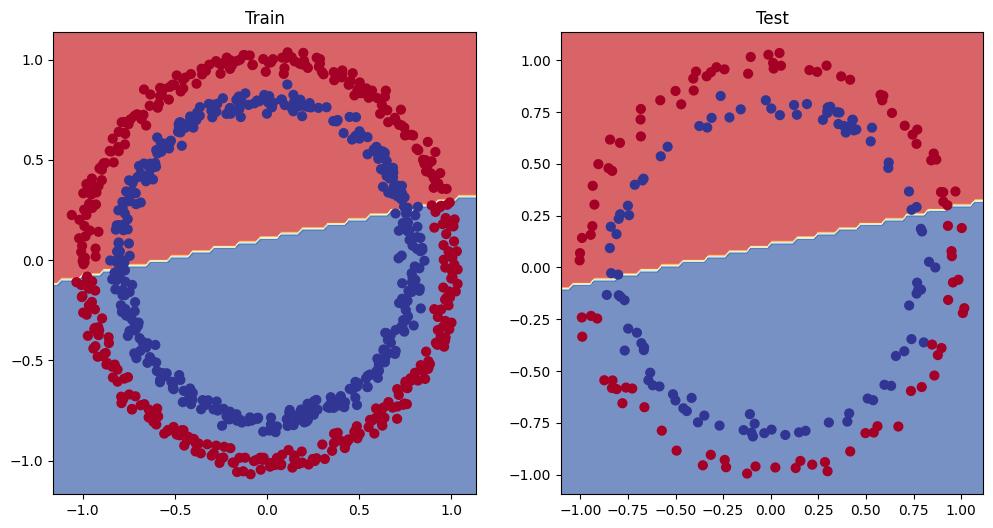

In [ ]:

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

In [ ]:
y_test.dim()

1

In [ ]:
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

### Improving a model (from a model perspective)

* Add more layers - gives the model more chances to learn about patterns in the data

* Add more hidden neurons - we ccould go from 5 hidden units to 10 hidden units

* Fit for longer 

* Changing the activation functions

* Change the learning rate   

* Change the loss function 


These options are from our models perspective because they directly deal with the model itself, rather than the data.

And because these options are all values we (ML engineers) can change, they are referred to as hyperparameters

For our particular lamodel, we would be:
  * Adding more hidden units: 5 --> 10
  * Increase the number of layers: 2 --> 3
  * increase the number of epochs: 100 -> 1000

In [ ]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features= 2, out_features=10)
        self.layer_2= nn.Linear(in_features=10, out_features= 10)
        self.layer_3= nn.Linear(in_features=10, out_features=1)

    def forward(self, x):
        #z = self.layer_1(x)
        #z = self.layer_2(z)
        #z = self.layer_3(z)
        #return z
        # Leveraging on speed ups on pytorch, we could rewrite as:
        return self.layer_3(self.layer_2(self.layer_1(x)))
    
    
model_2 = CircleModelV1().to(device)
model_2

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
1 # Create a loss function
loss_fn  = nn.BCEWithLogitsLoss()

2 # Create an optimizer
optimiser = torch.optim.SGD(params=model_2.parameters(),
                            lr = 0.1)
3 # Write a training and evaluation loop for model_1


3

In [ ]:
# Training Loop
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

epochs = 10000
for epoch in range(epochs):
    # forward pass
    m2_logits = model_2(X_train).squeeze()
    m2_pred = torch.round(torch.sigmoid(m2_logits))

    # calculate the loss
    loss = loss_fn(m2_logits,
                   y_train)
    
    optimizer.zero_grad
    
    loss.backward()

    optimizer.step()

    # Testing
    model_2.eval()
    with torch.inference_mode():
        # Forward pass 
        test_logits = model_2(X_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))
        # 2. Calculate Loss
        loss = loss_fn(y_logits, y_train)
        acc = accuracy_fn(y_true = y_train,
                          y_pred = y_pred) 

        #Print out what's happenin'
        if epoch % 100 == 0:
            print(f"Epoch: {epoch} | Loss: {loss: .5f}, Accuracy: {acc: .2f}% | Test loss: {test_loss: .5f}, Test acc: {test_acc: .2f}%")

Epoch: 0 | Loss:  0.69331, Accuracy:  49.38% | Test loss:  0.69270, Test acc:  53.00%
Epoch: 100 | Loss:  0.69331, Accuracy:  49.38% | Test loss:  0.69270, Test acc:  53.00%
Epoch: 200 | Loss:  0.69331, Accuracy:  49.38% | Test loss:  0.69270, Test acc:  53.00%
Epoch: 300 | Loss:  0.69331, Accuracy:  49.38% | Test loss:  0.69270, Test acc:  53.00%
Epoch: 400 | Loss:  0.69331, Accuracy:  49.38% | Test loss:  0.69270, Test acc:  53.00%
Epoch: 500 | Loss:  0.69331, Accuracy:  49.38% | Test loss:  0.69270, Test acc:  53.00%
Epoch: 600 | Loss:  0.69331, Accuracy:  49.38% | Test loss:  0.69270, Test acc:  53.00%
Epoch: 700 | Loss:  0.69331, Accuracy:  49.38% | Test loss:  0.69270, Test acc:  53.00%
Epoch: 800 | Loss:  0.69331, Accuracy:  49.38% | Test loss:  0.69270, Test acc:  53.00%
Epoch: 900 | Loss:  0.69331, Accuracy:  49.38% | Test loss:  0.69270, Test acc:  53.00%
Epoch: 1000 | Loss:  0.69331, Accuracy:  49.38% | Test loss:  0.69270, Test acc:  53.00%
Epoch: 1100 | Loss:  0.69331, Acc

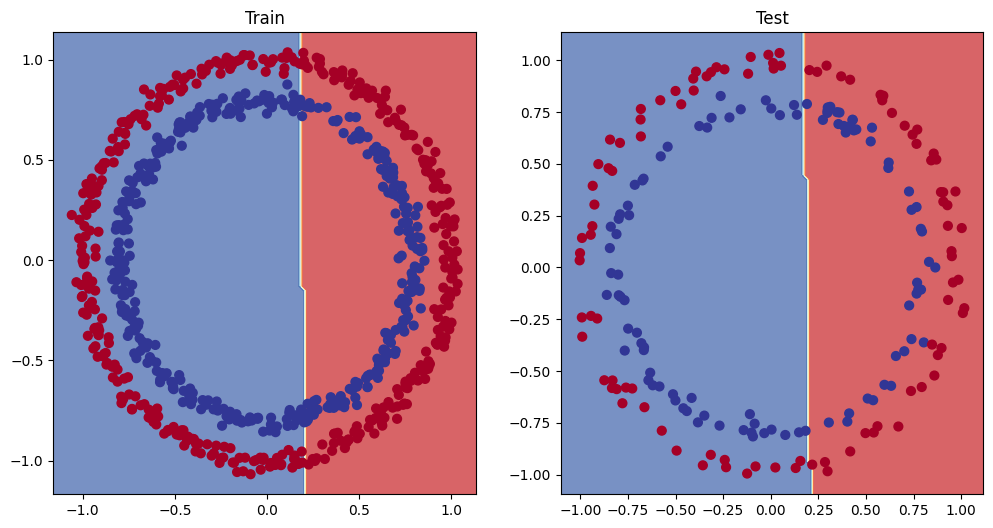

In [ ]:
# Plot the decision boundary of the model

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_2, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_2, X_test, y_test)


### 5.1 Preparing Data to see if our model can fit a straight line 

One way to trouble shoot to a larger problem is testing out a smaller problem.

In [ ]:
# Create some data (same as data used for first course)

weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# Create data 
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias  # Linear regression formular 

# check the data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [ ]:
# Create trai and test splits 
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split: ], y_regression[train_split:]

len(X_train_regression), len(X_test_regression), len(y_train_regression), len(y_test_regression)

(80, 20, 80, 20)

In [ ]:
plot_predictions(train_data = X_train_regression,
                 train_label = y_train_regression,
                 test_data = X_test_regression,
                 test_label = "y_test_prediction")

NameError: name 'plot_predictions' is not defined

In [ ]:
### Adjusting `model_2` to fit a straight line 

### Same architecture as model_2 but using nn.sequential. This allows for faster use and makes it easy to chnage the hyperparameters

model_3 = nn.Sequential(
    nn.Linear(in_features = 1, out_features = 10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_3


Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params =model_3.parameters(),
                            lr = 0.01)

# Train the model 
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = y_test_regression.to(device), y_test_regression.to(device)

# set the number of epochs
Epochs = 1000

for epoch in range(epochs):
    model_3.train()

    mod3_pred = model_3(X_train_regression)

    loss = loss_fn(mod3_pred, X_train_regression)
    optimizer.zero_grad()

    mod3_acc = accuracy_fn(y_true= X_train_regression,
                           y_pred=mod3_pred)
    loss.backward()
    optimizer.step()

    model_3.eval()
    with torch.inference_mode():
        mod3_test_preds = model_3(X_test_regression)
        test_loss = loss_fn(y_test_regression, mod3_test_preds)
        test_accuracy = accuracy_fn(y_true= y_test_regression, 
                                    y_pred = mod3_test_preds)
        if epoch % 100 ==0:
            print(f"Epoch: {epoch} | Loss: {loss} | Accuracy: {mod3_acc} | Test Loss: {test_loss} | Test Accuracy: {test_accuracy}")


Epoch: 0 | Loss: 0.008695246651768684 | Accuracy: 0.0 | Test Loss: 0.03629909083247185 | Test Accuracy: 0.0
Epoch: 100 | Loss: 0.009379120543599129 | Accuracy: 0.0 | Test Loss: 0.03911492973566055 | Test Accuracy: 0.0
Epoch: 200 | Loss: 0.008834747597575188 | Accuracy: 0.0 | Test Loss: 0.039381079375743866 | Test Accuracy: 0.0
Epoch: 300 | Loss: 0.008825821802020073 | Accuracy: 0.0 | Test Loss: 0.03915765509009361 | Test Accuracy: 0.0
Epoch: 400 | Loss: 0.008589958772063255 | Accuracy: 0.0 | Test Loss: 0.0354582779109478 | Test Accuracy: 0.0
Epoch: 500 | Loss: 0.00877758115530014 | Accuracy: 0.0 | Test Loss: 0.03765053302049637 | Test Accuracy: 0.0
Epoch: 600 | Loss: 0.009127494879066944 | Accuracy: 0.0 | Test Loss: 0.03815960884094238 | Test Accuracy: 0.0
Epoch: 700 | Loss: 0.008720926940441132 | Accuracy: 0.0 | Test Loss: 0.038513824343681335 | Test Accuracy: 0.0
Epoch: 800 | Loss: 0.008374038152396679 | Accuracy: 0.0 | Test Loss: 0.03470943123102188 | Test Accuracy: 0.0
Epoch: 900 |